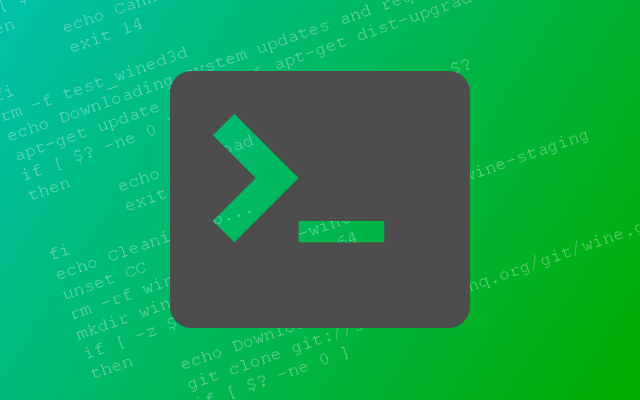

![Terminal](https://drive.google.com/uc?id=1YdlUUgwxr1ubVV48dm5bEYhYsMfSpzC_)

## Argumentos en la Línea de Comandos

Cuando estamos creando una aplicación, normalmente querremos poder decirle a nuestra aplicación cómo hacer algo. Hay dos métodos populares para realizar esta tarea. 

**Podemos hacer que nuestra aplicación acepte argumentos de línea de comandos o podemos crear una interfaz gráfica de usuario.**

Las interfaces de línea de comandos son útiles cuando necesitas ejecutar tu código en un servidor. La mayoría de los servidores no tienen un monitor conectado, especialmente si son servidores Linux. En esos casos, es posible que no puedas ejecutar una interfaz gráfica de usuario aunque quisieras.

Python viene con una biblioteca integrada llamada **<font color='green'>argparse</font> que puede usar para crear una interfaz de línea de comandos.** 

En este Notebook, aprenderemos acerca de lo siguiente:

* **Paso de argumentos**
* **Creación de mensajes útiles**
* **Adición de alias**
* **Uso de argumentos mutuamente excluyentes**
* **Creación de una utilidad de búsqueda simple**


<font color='green'>**¡Ahora es el momento de comenzar a analizar argumentos desde la línea de comandos!**</font>

### <font color='green'>1. Paso de Argumentos con Sys</font>

Antes de aprender a usar argparse, es bueno saber que hay otra forma de pasar argumentos a un script de Python. 

**Podemos pasar cualquier argumento a un script de Python y acceder a esos argumentos utilizando el <font color='green'>módulo sys.**</font>

Para ver cómo funciona, crea un archivo llamado **sys_args.py** inserta el siguiente código en él:

In [ ]:
import sys
 

def main():
    print ("Número de parámetros: ", len(sys.argv))
    print ("Lista de argumentos: ", sys.argv)

main()

Este código **importa sys e imprime lo que esté en sys.argv.** El atributo argv contiene una lista de todo lo que se pasó al script, siendo el primer elemento el propio script.

**¿Qué sucede cuando ejecutas este código en el CMD?**

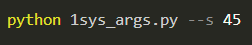

**Devuelve:**

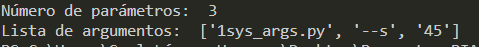

Con esto podríamos realizar operaciones teniendo en cuenta los parámetros recibidos. Por ejemplo:

In [ ]:
import sys
 

def main():
    print ("Número de parámetros: ", len(sys.argv))
    print ("Lista de argumentos: ", sys.argv)
    if sys.argv[1] == '--s':
        print("Realizamos operación asociada con --s")

main()

Nos funcionaria bien. ¿Pero qué ocurre si ponemos el parámetro en otro orden? **Dejaría de funcionar**

Podría implementarse? Sí, pero requeriria analizar la lista de parámetros. 

### 1.1 Problemas del paso de Argumentos son Sys

**El problema con el uso de sys.argv es que no tiene control sobre los argumentos que se pueden pasar a su aplicación:**

* **No puedes ignorar los argumentos**
* **No puede crear argumentos predeterminados**
* **Realmente no puedes decir cuál es un argumento válido en absoluto**

Es por eso que usar argparse es el camino a seguir cuando se trabaja con la biblioteca estándar de Python. El módulo argparse es muy poderoso y útil. Pensemos en el proceso que sigue una aplicación desde la línea de comandos:

* **Pasar el nombre del archivo**
* **Hacer algo a ese archivo en tu programa**
* **Mostrar el resultado**

Veamos un ejemplo genérico de cómo podría funcionar. **Crea el fichero 2argparse.py y agregua el siguiente código:**

In [ ]:
import argparse
 
parser = argparse.ArgumentParser('Parámetros programa 2argparse')# Descripción nuestro script en linea de comandos
parser.add_argument("-v", "--verbose", help="Mostrar información de depuración", action="store_true")# agrego un nuevo parámetro denominado -v
#el parámetro action = "store_true" le indica que detrás del parámetro no va ningun valor.(prueba a quitarlo y ver qué ocurre.)
args = parser.parse_args()#recupero los parámetros del objeto parser
 
# Aquí procesamos lo que se tiene que hacer con cada argumento
if args.verbose:
    print("depuración activada!!!")

Veamos otro ejemplo más completo. **Crea el fichero 3argparse.py con el siguiente código:**

In [ ]:
import argparse

def file_parser(input_file, output_file=''):

    print(f'Procesando {input_file}')
    print('Fin procesado')
    if output_file:
        print(f'Creando {output_file}')

def main():
    parser = argparse.ArgumentParser('Parser de ficheros')
    parser.add_argument('-i', '--infile', help='Fichero de entrada')#creamos un argumento para recibir un fichero de entrada
    parser.add_argument('-o', '--out', help='Fichero de salida')#creamos otro argumento para el nombre de un fichero de salida
    args = parser.parse_args()#recupero los argumentos
    if args.infile:#control de argumentos
        file_parser(args.infile, args.out)


main()

**Prueba qué ocurre con las distintas combinaciones de argumentos**

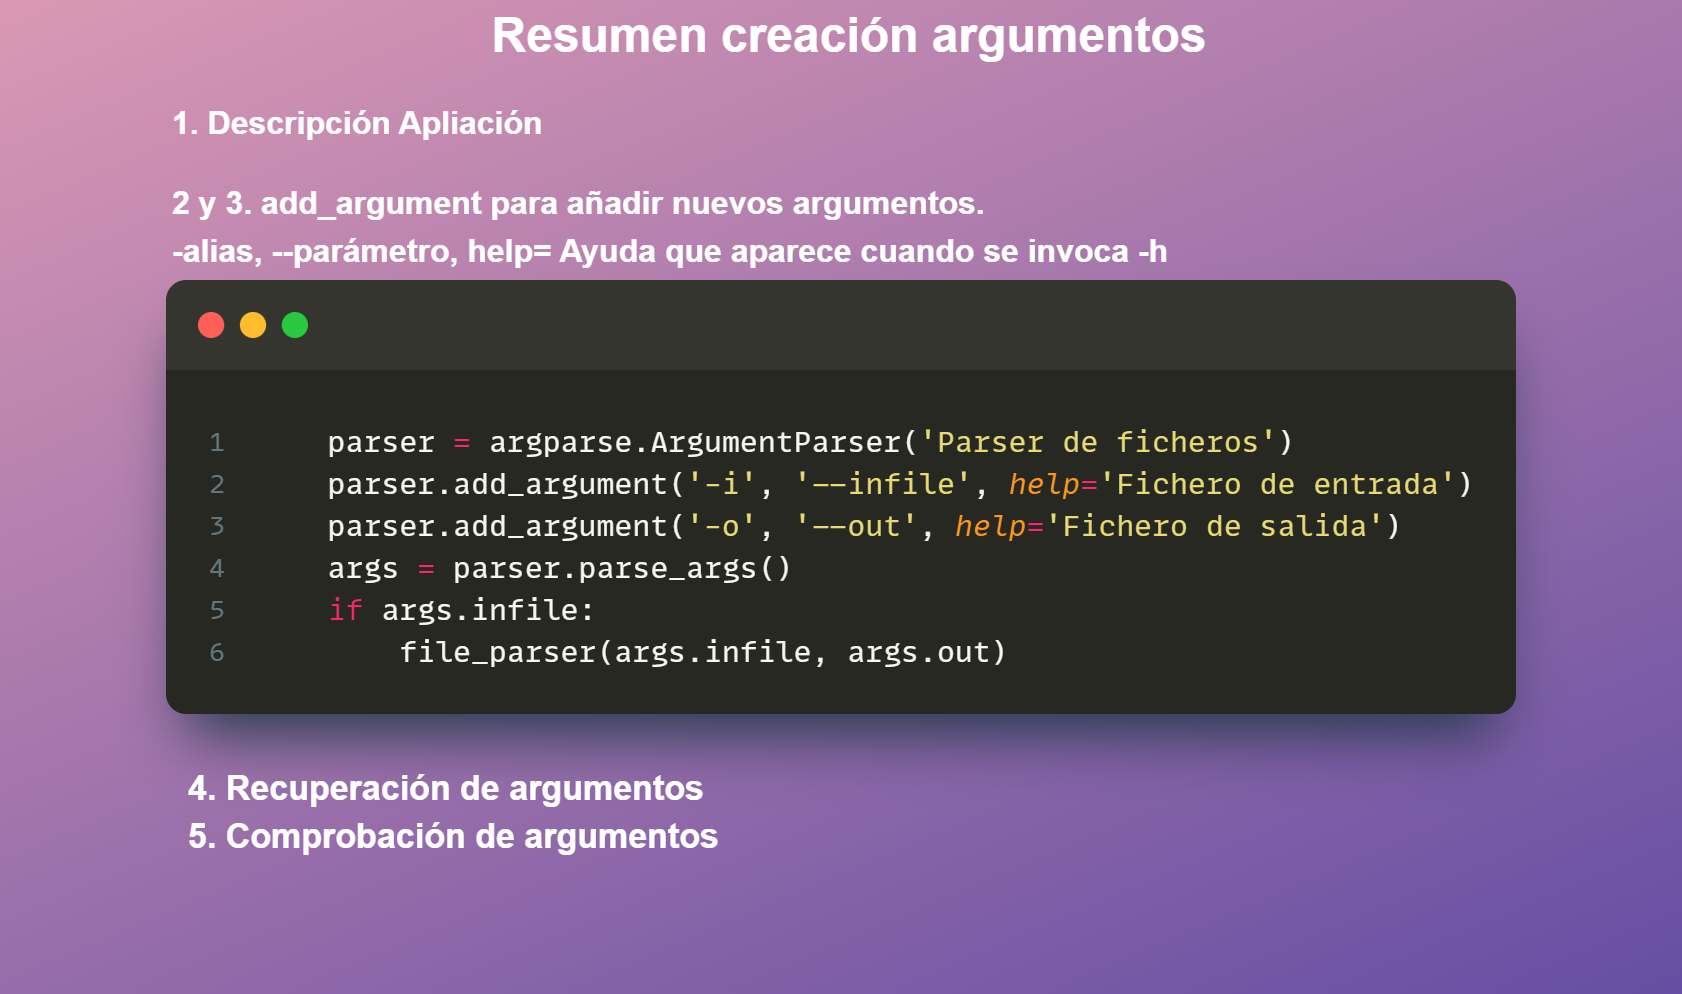

![estructura](https://drive.google.com/uc?id=1wBGeG0J-kP-vxjcxYHxcYThNYY-06mK_)

### <font color='green'>2. Creación de mensajes de Ayuda</font>

La biblioteca argparse creará automáticamente un mensaje de ayuda para tu aplicación usando la información que proporcionaste cuando creaste cada argumento.

**Prueba a ejecutar tu scrip con la opción -h**

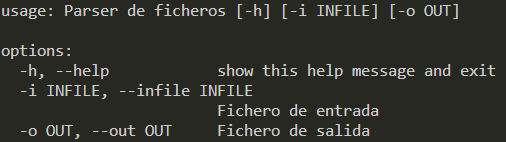

Puedes hacer que tu ayuda sea más informativa dando una descripción y un epílogo.

Copia el siguiente código en un nuevo scrip denominado **4argparse.py** y pruebalo en tu consola.

In [ ]:
import argparse

def file_parser(input_file, output_file=''):

    print(f'Procesando {input_file}')
    print('Fin procesado')
    if output_file:
        print(f'Creando {output_file}')

def main():
    parser = argparse.ArgumentParser('Pyparse',
            description='PyParse - El procesador de FIcheros',
            epilog='Gracias por ver PyParse!',
            )
    parser.add_argument('-i', '--infile', help='Fichero de entrada')
    parser.add_argument('-o', '--out', help='Fichero de salida')
    args = parser.parse_args()
    if args.infile:
        file_parser(args.infile, args.out)


main()

**Ahora puedes ver la nueva descripción y epílogo en su resultado de ayuda. Esto le da a tu aplicación de línea de comandos un toque extra.**


### <font color='green'>3. Argumentos opcionales, por defecto y obligatorios.</font>

**Default**

Todos los argumentos opcionales y algunos argumentos posicionales pueden ser omitidos en la línea de comandos. El argumento de palabra clave default de add_argument(), cuyo valor por defecto es None, especifica qué valor debe usarse si el argumento de línea de comandos no está presente. 

Para los argumentos opcionales, **se usa el valor default cuando la cadena de caracteres de opción no está presente en la línea de comandos:**

**required**

En general, el módulo argparse asume que los indicadores (flags) como -f y --bar señalan argumentos opcionales, que siempre pueden ser omitidos en la línea de comandos. 

**Para hacer una opción requerida, se puede especificar ``True`` para el argumento de palabra clave ``required=`` en add_argument():**


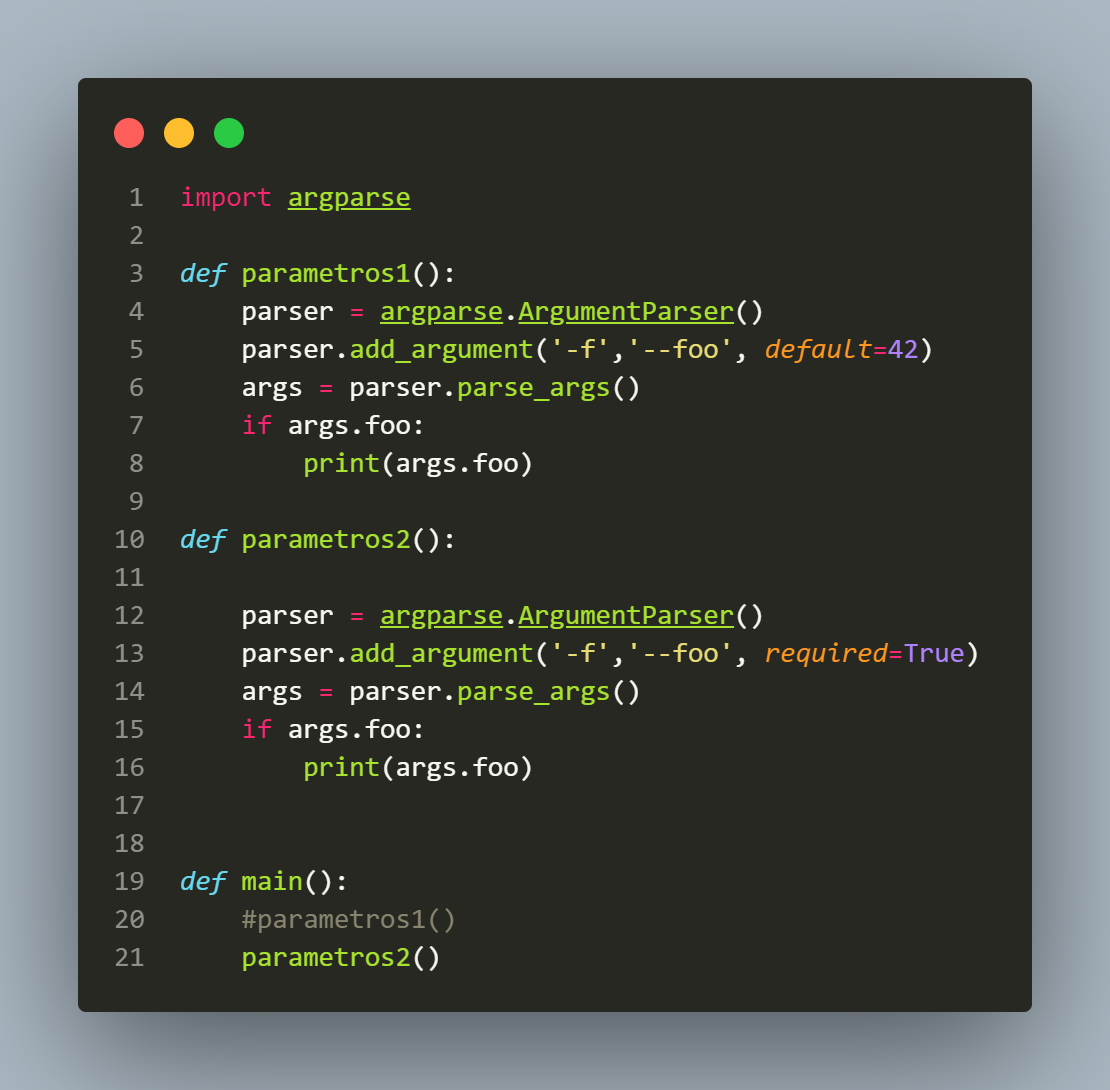

![defecto_obligatorios](https://drive.google.com/uc?id=1sX2w_iW0a77JKGY2jlAhcMNOVv2RyCPD)

Desarrolla el script anterior para probar los parámetros por defecto y obligatorios.

### <font color='green'>4.Uso de argumentos mutuamente excluyentes</font>

**A veces necesitamos que nuestra aplicación acepte algunos argumentos pero no otros.**

Por ejemplo, podemos desear limitar nuestra aplicación para que solo pueda crear o eliminar archivos, pero no ambos al mismo tiempo.

¡El módulo argparse proporciona el método <font color='green'>**add_mutually_exclusive_group()**</font> que hace exactamente eso!

Cambia los argumentos del script **4argparse.py** para que sean mutuamente excluyentes agregándolos a un objeto de grupo como en el siguiente ejemplo. 

Crea un fichero que se denomine **6argparseexcluentes.py y pruebalo.**

In [ ]:
import argparse


def file_parser(input_file, output_file=''):

    print(f'Procesando {input_file}')
    print('Fin procesado')
    if output_file:
        print(f'Creando {output_file}')


def main():
    parser = argparse.ArgumentParser('Pyparse',
                                     description='PyParse - El procesador de FIcheros',
                                     epilog='Gracias por ver PyParse!',
                                     add_help=False
                                     )
    group = parser.add_mutually_exclusive_group()                                     
    group.add_argument('-i', '--infile', help='Fichero de entrada')
    group.add_argument('-o', '--out', help='Fichero de salida')
    args = parser.parse_args()
    if args.infile:
        file_parser(args.infile, args.out)

main()

**Observa qué ocurre si se ponen ambos parámetros**

### 5. Creación de un script de búsqueda de ficheros simple

La aplicación que vamos a crear en esta sección debería poder buscar archivos de un tipo específico. Para hacerlo más interesante, vamos a agregar un argumento adicional que le permita buscar opcionalmente tamaños de archivo igual o superior al parámetro introducido.

Podemos usar el **módulo glob** de Python para buscar tipos de archivos. Puedes leer todo sobre este módulo aquí:
* https://docs.python.org/3/library/glob.html


Sin embargo, dado que deseamos poder filtrar opcionalmente los archivos devueltos por el tamaño del archivo, usaremos
<font color='green'>**pathlib**</font> ya que el módulo glob en sí mismo no proporciona el tamaño del archivo.


<font color='green'>**¡Comencemos!**</font>

1. Crea un archivo llamado **pybusqueda.py**


2. Implementa una función denominada **busqueda_fichero** que reciba 3 parámetros: 
    * path: ruta donde deberá buscar los ficheros.
    * extensión: extensión de los ficheros a buscar 
    * tamaño del fichero: Tamaño en bytes de los ficheros, por defecto tendrá valor None. 
    
    Esta función buscará en el path los ficheros con la extensión y tamaños (si tiene algún valor) introducidos y devolverá una lista con los nombres de los archivos que cumplan los requisitos de búsqueda.
    
    
3. Crea una función **main** que implemente la interfaz de línea de comandos y llame a la función busqueda_fichero. 

4. Implementa una función para presentar los resultados de la búsqueda.

5. Crea una nueva version del script que se denomine **pybusqueda_v2.py** que permita:

    * **Buscar por más de una extensión. Deberás investigar como recoger más de un valor para el parámetro de extensión.**
    * **Buscar por un rango de tamaños en bytes, debe aceptar 2 numeros enteros. Por ejemplo entre 100 - 500 bytes**
    
    
6. Prueba tus scrips introduciendo distintos valores en tus parámetros.    
    
Documentación arparse - Analizador sintáctico (Parser):

https://docs.python.org/es/3/library/argparse.html#


### Ejemplos de ejecución:

1. Filtrado por varias extensiones

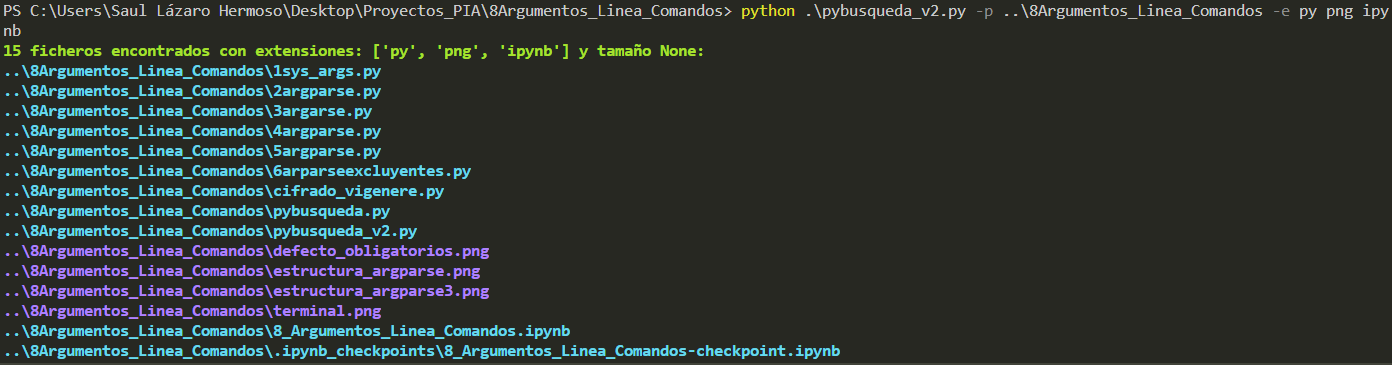

![filtrado varias extensiones](https://drive.google.com/uc?id=1XS0a-34fR_6MfBqC2rHbVLQxAIo_Cq6y)



2. Filtrado por varias extensiones y rango de tamaño:

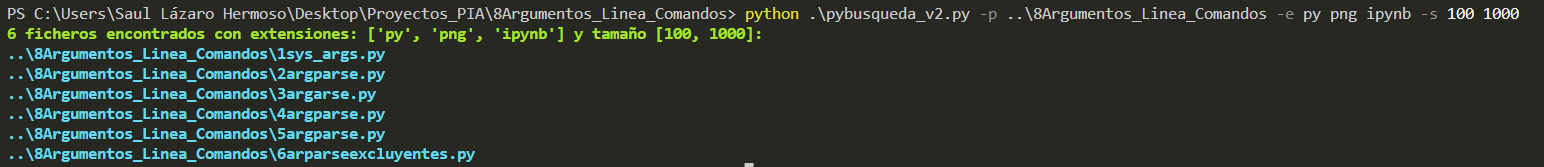

![filtrado varias extensiones y tamaño](https://drive.google.com/uc?id=1k5LXIoMzs92HKp8PiMocgE14r4BLfDZN)

3. No hay ficheros con los criterios de búsqueda:

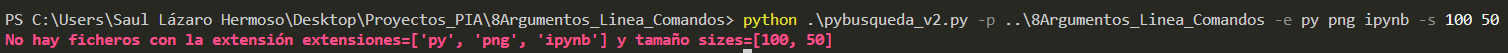

![no criterios](https://drive.google.com/uc?id=1KrnJ0zh-w-_h71NR6zOh9E9QJWJB1QBO)


### Solución:


## <font color='orange'>Ejercicios</font>

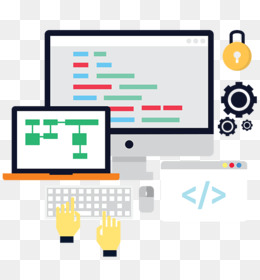

### Ejercicio 1 - Cifrado Vigenere

**Desarrolla un script que relize un cifrado o descifrado de Vigenere de un mensaje.**

El cifrado Vigenere consiste en utilizar una palabra como clave para cifrar el mensaje y funciona de la siguiente forma:

En nuestro alfabeto existen 27 letras. 

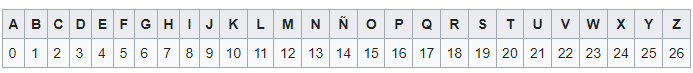

![alfabeto castellano](https://drive.google.com/uc?id=1dSNq49BqbgUgBiw_2Y3hnUN6D1dhVHu_)

Cada letra ocupa una posición. 

Lo que hace el cifrado Vigenere es **enfrentar las letras del mensaje a cifrar con la palabra clave.** Por ejemplo:

Mensaje a cifrar: PROGRAMACIONDEIA
Palabra clave: COVID

Ahora enfrentamos el mensaje a cifrar y la clave hasta que llegue al final del mensaje, si se corta no pasa nada.

**PROGRAMACIONDEIA**

**COVIDCOVIDCOVIDC**

Una vez las tenemos enfrentadas, sumamos la posición que ocupa cada letra enfrentada:

p => 16

C => 2

Resultado = 18

R => 18

O => 15

resultado = 33 


Al resultado le hacemos el módulo con el total de letras del alfabeto y la posición resultante será la letra con la que codificamos esa posición. Siguiendo con el ejemplo anterior

**18 % 27 = 18 => le corresponderia la letra R**

**33 % 27 = 6  => le correspondería la letra G**


El script puede recibir 3 parámetros:
* **-c seguido de una palabra para indicar que queremos cifrar esa palabra**
* **-d seguido de una palabra descifrar la palabra indicada.**
* **-k seguido de una palabra que funcionará como clave para el cifrado/descifrado**

No podemos cifrar y descifrar a la vez.

Vamos a tener en cuenta solo las letras en mayúsculas y nuestros mensajes irán sin espacios ni puntuaciones. Si en la terminal los mensajes se introducen en minúsculas, internamente lo cambiaremos a mayúsculas.

Ejemplo de uso:
    
   cifrar paralabra: **python cifrado_vigenere.py -c PROGRAMACIONDEIA -k covid**
    
   descifrado: **python cifrado_vigenere.py -d RGKÑUCAVKLQBYMLC -k covid**        
   
### Solución:   

In [ ]:
# Importamos la libreria para trabajar con los argumentos en la linea de comando    
import argparse

# Alfabeto
alfabeto = "ABCDEFGHIJKLMNÑOPQRSTUVWXYZ"

# Metodo para cifrar un mensaje con una clave
def cifrar(mensaje, clave):
    mensaje = mensaje.upper()
    clave = clave.upper()
    # Variable que almacena el resultado del mensaje cifrado
    resultado = ""
    # Recorremos letra a letra el mensaje, obteniendo el indice de cada letra del mensaje de la clave
    for i, letra in enumerate(mensaje):
        posicionMensaje = alfabeto.index(letra)
        posicionClave = alfabeto.index(clave[i % len(clave)])
        # Aplicamos la formula de cifrado del cifrado Vigenere
        posicionCifrada = (posicionMensaje + posicionClave) % len(alfabeto)
        # Agregamos la letra cifrada al resultado
        resultado += alfabeto[posicionCifrada]
    return resultado

# Metodo para descifrar un mensaje con una clave
def descifrar(mensaje, clave):
    mensaje = mensaje.upper()
    clave = clave.upper()
    # Variable que almacena el resultado del mensaje descifrado
    resultado = ""
    # Recorremos letra a letra el mensaje, obteniendo el indice de cada letra del mensaje de la clave
    for i, letra in enumerate(mensaje):
        posicionMensaje = alfabeto.index(letra)
        posicionClave = alfabeto.index(clave[i % len(clave)])
        # Aplicamos la formula de descifrado del cifrado Vigenere
        posicionDescifrada = (posicionMensaje - posicionClave) % len(alfabeto)
        # Agregamos la letra descifrada al resultado
        resultado += alfabeto[posicionDescifrada]
    return resultado

# Metodo principal del programa
def main():
    # Creamos el parser para los argumento de la linea de comandos
    parser = argparse.ArgumentParser(description="Cifrado/Descifrado Vigenere")
    grupo = parser.add_mutually_exclusive_group()
    grupo.add_argument("-c", "--cifrar", help="Mensaje a cifrar")
    grupo.add_argument("-d", "--descifrar", help="Mensaje a descifrar")
    parser.add_argument("-k", "--key", required=True, help="Clave para el cifrado/descifrado")
    args = parser.parse_args()
    # Comprobamos los argumentos y realizamos el cifrado o el descifrado del mensaje
    if args.cifrar:
        resultado = cifrar(args.cifrar, args.key)
        print(f"Mensaje cifrado: {resultado}")
    elif args.descifrar:
        resultado = descifrar(args.descifrar, args.key)
        print(f"Mensaje descifrado: {resultado}")

main()